# Delivery-Time Prediction — Kaggle Inference Notebook (uses the saved model)

This notebook is **self-contained** (no external imports) and loads our pre-trained model to
produce `submission.csv`. It does **not** retrain.

## ▶ Setup before running (do this once)
1. **Add the competition data:** right panel → **Add Input** → search this competition → add it.
   (Its `train.csv` / `test.csv` appear under `/kaggle/input/...`.)
2. **Add the saved model:** upload the local **`model/`** folder (the 4 booster files +
   `meta.json`) as a **Kaggle Dataset**, then **Add Input** → add that dataset.
3. **Run All.** The notebook finds the files automatically and writes `submission.csv` to the
   output, ready to submit.

> Why the model is needed: training happens offline; here we just load the frozen boosters and
> apply them. See `approach.md` / `technical.md` for the full method.

## 1. Imports & locate the input files (auto-detect)

In [1]:
import os, glob, json
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.cluster import KMeans
import lightgbm as lgb
import xgboost as xgb

SEED = 42
TARGET = "delivery_time_days"

def find_file(name, roots=("/kaggle/input", ".", "data", "..", "model")):
    for root in roots:
        hits = sorted(glob.glob(os.path.join(root, "**", name), recursive=True))
        if hits:
            return hits[0]
    raise FileNotFoundError(f"could not find {name} under {roots} — did you add the inputs?")

train_path = find_file("train.csv")
test_path  = find_file("test.csv")
meta_path  = find_file("meta.json")          # comes from the uploaded model dataset
MODEL_DIR  = os.path.dirname(meta_path)
OUT_DIR    = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."
print("train :", train_path)
print("test  :", test_path)
print("model :", MODEL_DIR)
print("output:", OUT_DIR)

train : .\data\train.csv
test  : .\data\test.csv
model : .\model
output: .


## 2. Feature pipeline (inlined — identical to how the model was trained)

In [2]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1); dl = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2*R*np.arcsin(np.sqrt(np.clip(a, 0, 1)))

def impute_city_coords(tr, te):
    both = pd.concat([tr, te], ignore_index=True, sort=False)
    for side in ["customer", "seller"]:
        city = f"{side}_city"
        for ax in ["lat", "lng"]:
            col = f"{side}_{ax}"
            both[col] = both[col].fillna(both.groupby(city)[col].transform("median"))
    ntr = len(tr)
    return both.iloc[:ntr].copy(), both.iloc[ntr:].reset_index(drop=True).copy()

BR_HOLIDAYS = pd.to_datetime([
    "2016-12-25","2017-01-01","2017-02-27","2017-02-28","2017-04-14","2017-04-21",
    "2017-05-01","2017-06-15","2017-09-07","2017-10-12","2017-11-02","2017-11-15",
    "2017-11-24","2017-12-25","2018-01-01","2018-02-12","2018-02-13","2018-03-30",
    "2018-04-21","2018-05-01","2018-05-31","2018-09-07","2018-10-12","2018-11-02",
    "2018-11-15","2018-11-23","2018-12-25"])

def base_features(df):
    f = pd.DataFrame(index=df.index)
    num = ["quantity","price","freight_value","product_weight_g","product_length_cm",
           "product_height_cm","product_width_cm","volume_cm3","product_photos_qty",
           "product_name_length","product_description_length",
           "customer_lat","customer_lng","seller_lat","seller_lng"]
    for c in num:
        f[c] = df[c].astype("float32")
    f["dist_km"] = haversine(df.customer_lat, df.customer_lng, df.seller_lat, df.seller_lng).astype("float32")
    f["abs_dlat"] = (df.customer_lat - df.seller_lat).abs().astype("float32")
    f["abs_dlng"] = (df.customer_lng - df.seller_lng).abs().astype("float32")
    f["same_city"] = (df.customer_city.astype(str) == df.seller_city.astype(str)).astype("int8")
    f["total_price"] = (df.price*df.quantity + df.freight_value).astype("float32")
    f["freight_per_price"] = (df.freight_value/(df.price+1e-3)).astype("float32")
    f["freight_per_kg"] = (df.freight_value/(df.product_weight_g/1000+1e-3)).astype("float32")
    f["freight_per_km"] = (df.freight_value/(f["dist_km"]+1.0)).astype("float32")
    f["price_per_item"] = (df.price/(df.quantity+1e-3)).astype("float32")
    f["density"] = (df.product_weight_g/(df.volume_cm3+1e-3)).astype("float32")
    f["weight_x_dist"] = (df.product_weight_g*f["dist_km"]).astype("float32")
    f["log_weight"] = np.log1p(df.product_weight_g).astype("float32")
    f["log_volume"] = np.log1p(df.volume_cm3).astype("float32")
    f["log_freight"] = np.log1p(df.freight_value).astype("float32")
    f["log_dist"] = np.log1p(f["dist_km"]).astype("float32")
    f["max_dim"] = df[["product_length_cm","product_height_cm","product_width_cm"]].max(axis=1).astype("float32")
    ts = pd.to_datetime(df["order_purchase_timestamp"])
    f["pur_year"] = ts.dt.year.astype("int16"); f["pur_month"] = ts.dt.month.astype("int8")
    f["pur_day"] = ts.dt.day.astype("int8"); f["pur_dow"] = ts.dt.dayofweek.astype("int8")
    f["pur_hour"] = ts.dt.hour.astype("int8"); f["pur_doy"] = ts.dt.dayofyear.astype("int16")
    f["pur_woy"] = ts.dt.isocalendar().week.astype("int16"); f["pur_quarter"] = ts.dt.quarter.astype("int8")
    f["is_weekend"] = (ts.dt.dayofweek >= 5).astype("int8")
    f["days_since_start"] = ((ts - pd.Timestamp("2016-09-01")).dt.total_seconds()/86400).astype("float32")
    f["doy_sin"] = np.sin(2*np.pi*ts.dt.dayofyear/365.25).astype("float32")
    f["doy_cos"] = np.cos(2*np.pi*ts.dt.dayofyear/365.25).astype("float32")
    f["dom_sin"] = np.sin(2*np.pi*ts.dt.day/31).astype("float32")
    f["dom_cos"] = np.cos(2*np.pi*ts.dt.day/31).astype("float32")
    f["is_holiday_season"] = (((ts.dt.month==11)&(ts.dt.day>=15))|(ts.dt.month==12)|
                              ((ts.dt.month==1)&(ts.dt.day<=10))).astype("int8")
    d2x = ((pd.to_datetime(ts.dt.year.astype(str)+"-12-25")-ts).dt.total_seconds()/86400)
    f["days_to_xmas"] = d2x.clip(-30,60).astype("float32")
    hol = BR_HOLIDAYS.values.astype("datetime64[ns]").astype("int64")
    tsv = ts.values.astype("datetime64[ns]").astype("int64")
    f["days_to_holiday"] = (np.min(np.abs(tsv[:,None]-hol[None,:]),axis=1)/86400e9).astype("float32")
    ap = pd.to_datetime(df["order_approved_at"])
    f["approval_delay_days"] = ((ap-ts).dt.total_seconds()/86400).astype("float32")
    f["approved_hour"] = ap.dt.hour.astype("float32"); f["approved_dow"] = ap.dt.dayofweek.astype("float32")
    f["approval_missing"] = ap.isna().astype("int8")
    return f

def add_geo_clusters(ftr, fte, n=30):
    for side in ["customer", "seller"]:
        cols = [f"{side}_lat", f"{side}_lng"]
        med = ftr[cols].median()
        km = KMeans(n_clusters=n, random_state=SEED, n_init=4)
        ftr[f"{side}_region"] = km.fit_predict(ftr[cols].fillna(med)).astype("int16")
        fte[f"{side}_region"] = km.predict(fte[cols].fillna(med)).astype("int16")
    ftr["route_region"] = ftr["seller_region"].astype(int)*1000 + ftr["customer_region"].astype(int)
    fte["route_region"] = fte["seller_region"].astype(int)*1000 + fte["customer_region"].astype(int)
    return ftr, fte

def oof_target_encode(tr_key, te_key, y, n_splits=5, smoothing=20.0, seed=SEED):
    tr_key = tr_key.astype(str).values; te_key = te_key.astype(str).values
    gm = y.mean(); oof = np.full(len(tr_key), gm, dtype="float64"); yv = y.values
    for ti, vi in KFold(n_splits, shuffle=True, random_state=seed).split(tr_key):
        agg = pd.DataFrame({"k":tr_key[ti],"y":yv[ti]}).groupby("k")["y"].agg(["mean","count"])
        sm = (agg["mean"]*agg["count"]+gm*smoothing)/(agg["count"]+smoothing)
        oof[vi] = pd.Series(tr_key[vi]).map(sm).fillna(gm).values
    agg = pd.DataFrame({"k":tr_key,"y":yv}).groupby("k")["y"].agg(["mean","count"])
    sm = (agg["mean"]*agg["count"]+gm*smoothing)/(agg["count"]+smoothing)
    return oof.astype("float32"), pd.Series(te_key).map(sm).fillna(gm).values.astype("float32")

def freq_encode(tr_s, te_s):
    vc = pd.concat([tr_s.astype(str), te_s.astype(str)]).value_counts()
    return (tr_s.astype(str).map(vc).astype("float32").values,
            te_s.astype(str).map(vc).astype("float32").values)

FREQ_COLS = ["seller_id","product_id","customer_city","seller_city",
             "product_category_name_english","customer_unique_id"]

def prepare(train_df, query_df):
    train_df = train_df.copy(); query_df = query_df.copy()
    y = train_df[TARGET].astype("float32")
    train_df, query_df = impute_city_coords(train_df, query_df)
    ftr = base_features(train_df); fte = base_features(query_df)
    ftr, fte = add_geo_clusters(ftr, fte, n=30)
    for col in FREQ_COLS:
        ftr[f"{col}_freq"], fte[f"{col}_freq"] = freq_encode(train_df[col], query_df[col])
    te_specs = [
        ("seller_id", train_df["seller_id"], query_df["seller_id"], 30.0),
        ("seller_city", train_df["seller_city"], query_df["seller_city"], 30.0),
        ("customer_city", train_df["customer_city"], query_df["customer_city"], 20.0),
        ("category", train_df["product_category_name_english"], query_df["product_category_name_english"], 30.0),
        ("cust_region", ftr["customer_region"], fte["customer_region"], 20.0),
        ("seller_region", ftr["seller_region"], fte["seller_region"], 20.0),
        ("route_region", ftr["route_region"], fte["route_region"], 15.0),
        ("product_id", train_df["product_id"], query_df["product_id"], 30.0),
    ]
    for name, ks, kt, sm in te_specs:
        o, t = oof_target_encode(ks, kt, y, smoothing=sm)
        ftr[f"te_{name}"] = o; fte[f"te_{name}"] = t
    cs = train_df["seller_id"].astype(str)+"_"+ftr["customer_region"].astype(str)
    ct = query_df["seller_id"].astype(str)+"_"+fte["customer_region"].astype(str)
    o, t = oof_target_encode(cs, ct, y, smoothing=20.0)
    ftr["te_seller_custregion"] = o; fte["te_seller_custregion"] = t
    drop = ["customer_region","seller_region","route_region"]
    ftr = ftr.drop(columns=drop); fte = fte.drop(columns=drop)
    cols = list(fte.columns)
    return ftr[cols], y.values.astype("float64"), fte[cols], cols

print("pipeline ready")

pipeline ready


## 3. Load the data and the saved model

In [3]:
train = pd.read_csv(train_path)
test  = pd.read_csv(test_path)
print("train:", train.shape, " test:", test.shape)

meta = json.load(open(meta_path))
boosters = []
for m in meta["models"]:
    fname = os.path.basename(m["path"])                      # stored path -> just the filename
    path = find_file(fname, roots=(MODEL_DIR, "/kaggle/input", "model", "."))
    if m["framework"] == "lgb":
        b = lgb.Booster(model_file=path)
    else:
        b = xgb.Booster(); b.load_model(path)
    boosters.append((m, b))
pd.DataFrame([{ "model": m["name"], "fw": m["framework"], "log": m["log_target"],
               "weight": m["weight"] } for m, _ in boosters])

train: (85159, 26)  test: (15029, 25)


,model,fw,log,weight
0,lgb_l1_log,lgb,True,0.474
1,lgb_l1_deep,lgb,False,0.335
2,lgb_l2_log,lgb,True,0.106
3,xgb_mae,xgb,False,0.085


## 4. Build features for the test set and predict

In [4]:
X_train, y, X_test, feat_cols = prepare(train, test)
X_test = X_test[meta["feat_cols"]]                            # exact training column order
lo, hi = meta["clip"]

blend, wsum = np.zeros(len(X_test)), 0.0
for m, b in boosters:
    p = b.predict(X_test) if m["framework"] == "lgb" else b.predict(xgb.DMatrix(X_test))
    if m["log_target"]:
        p = np.expm1(p)
    blend += m["weight"] * np.clip(p, lo, hi); wsum += m["weight"]
pred = np.clip(blend / wsum, lo, hi)
print(f"predicted {len(pred)} orders  ->  median {np.median(pred):.2f}  mean {pred.mean():.2f} days")

predicted 15029 orders  ->  median 7.67  mean 8.16 days


## 5. Write the submission

In [5]:
sub = pd.DataFrame({"id": np.arange(len(pred)), "delivery_time_days": np.round(pred, 2)})
out_path = os.path.join(OUT_DIR, "submission.csv")
sub.to_csv(out_path, index=False)
print("wrote", out_path)
sub.head()

wrote .\submission.csv


,id,delivery_time_days
0,0,13.13
1,1,3.52
2,2,10.66
3,3,3.27
4,4,8.52


## 6. (Bonus) What drives the predictions

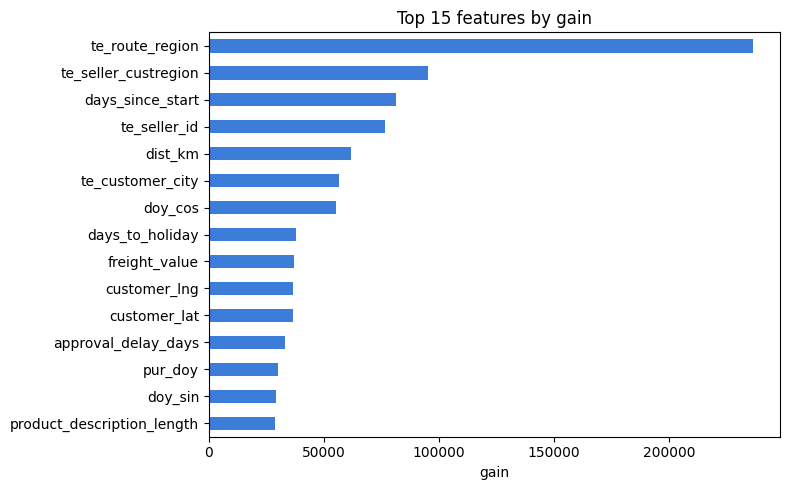

te_route_region               236267.0
te_seller_custregion           95237.0
days_since_start               81318.0
te_seller_id                   76521.0
dist_km                        61942.0
te_customer_city               56722.0
doy_cos                        55128.0
days_to_holiday                37808.0
freight_value                  37095.0
customer_lng                   36553.0
customer_lat                   36431.0
approval_delay_days            32891.0
pur_doy                        30074.0
doy_sin                        29078.0
product_description_length     28931.0
dtype: float64

In [6]:
top = next(b for m, b in boosters if m["framework"] == "lgb")
imp = pd.Series(top.feature_importance(importance_type="gain"),
                index=top.feature_name()).sort_values(ascending=False).head(15)
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5)); imp[::-1].plot.barh(color="#3b7dd8")
plt.title("Top 15 features by gain"); plt.xlabel("gain"); plt.tight_layout(); plt.show()
imp.round(0)

## Done ✅
`submission.csv` is in the output — open the **Output** tab and **Submit to Competition**, or use
*Save Version → Submit*. The model reproduces our locked **2.741** result.